In [21]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.io import imread
from skimage import data, exposure, color
from skimage.feature import blob_log

In [22]:
# Set random seed for reproducibility
seed_value = 123
np.random.seed(seed_value)

In [23]:
# Basic exploration by reading local image
img_path = 'image_data/elephant.png'  # Path to the elephant image
img = imread(img_path)
print("Image shape:", img.shape)  # Height x Width x Channels
print("Image size:", img.size)    # Multiplication of H x W x C

Image shape: (310, 341, 4)
Image size: 422840


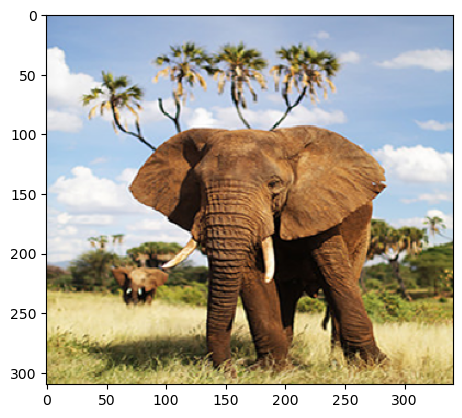

In [24]:
# Display the image
plt.imshow(img)
plt.show()

Normalized image type: <class 'numpy.ndarray'>
Normalized image shape: (310, 341, 4)


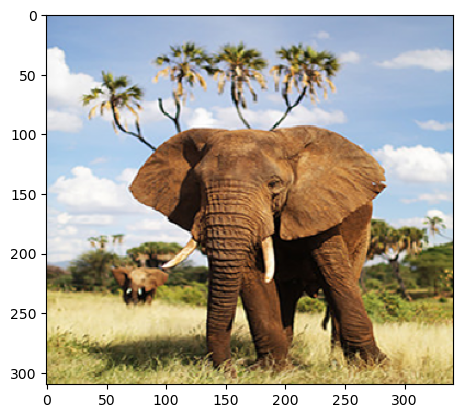

In [25]:
# Normalize the image
x = img / 255
print("Normalized image type:", type(x))
print("Normalized image shape:", x.shape)
plt.imshow(x)
plt.show()

Gray image shape: (310, 341)


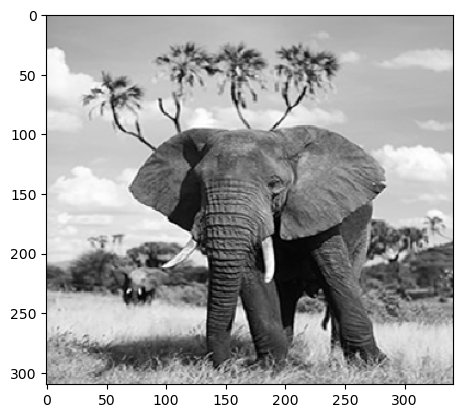

In [26]:
# Gray image reading
img_gray = imread(img_path, as_gray=True)
print("Gray image shape:", img_gray.shape)
plt.imshow(img_gray, cmap='gray')
plt.show()

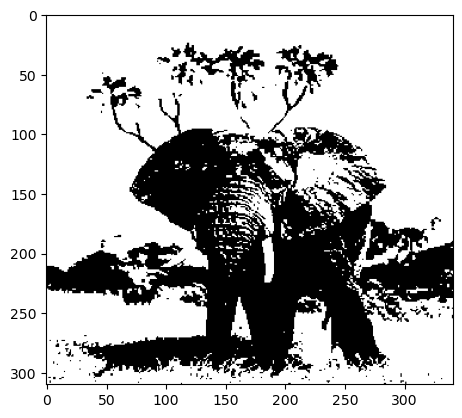

In [27]:
# Gray to black and white transformation
cutoff = np.max(img_gray) / 2
img_gray[img_gray < cutoff] = 0
img_gray[img_gray >= cutoff] = 1
plt.imshow(img_gray, cmap='gray')
plt.show()

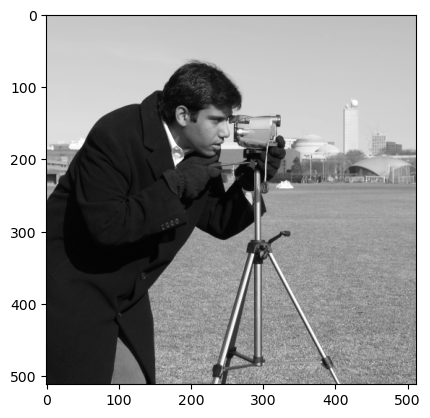

In [28]:
# Basic exploration of inbuilt images and features
camera = data.camera()
plt.imshow(camera, cmap='gray')
plt.show()

In [29]:
# Count white dots using blob detection
im = imread("./image_data/wint_sky.gif")
im = np.squeeze(im)
blobs_log = blob_log(im, max_sigma=30, num_sigma=10, threshold=.1)
blobs_log[:, 2] = blobs_log[:, 2] * np.sqrt(2)
print("Number of white dots counted:", len(blobs_log))

Number of white dots counted: 308


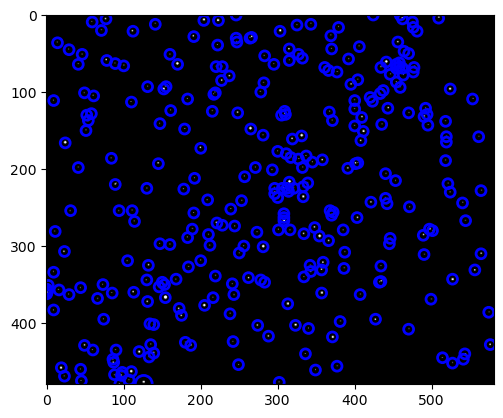

In [35]:
# Visualize detected blobs
fig, ax = plt.subplots()
plt.imshow(im, cmap='gray')
for blob in blobs_log:
    y, x, r = blob
    c = plt.Circle((x, y), r+5, color='blue', linewidth=2, fill=False)
    ax.add_patch(c)
plt.show()

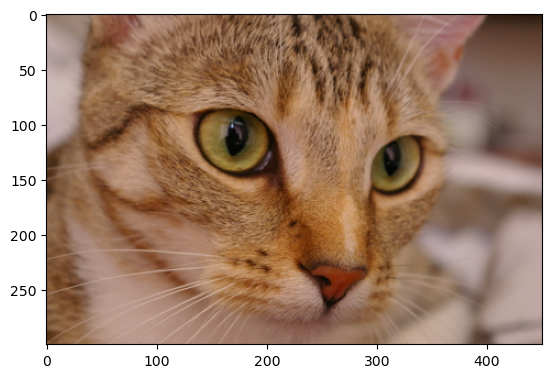

In [32]:
# Color image manipulation
cat = data.chelsea()
plt.imshow(cat)
plt.show()

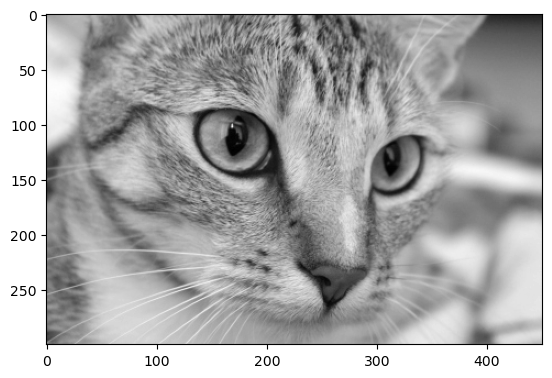

In [36]:
# Convert to grayscale
cat_gray = color.rgb2gray(cat)
plt.imshow(cat_gray, cmap='gray')
plt.show()

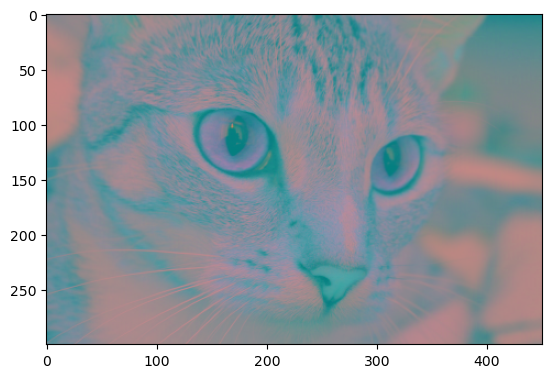

In [37]:
# LAB color space
lab_image = color.rgb2lab(cat)
lab_image_rescaled = (lab_image + [0, 128, 128]) / [100, 255, 255]
plt.imshow(lab_image_rescaled)
plt.show()

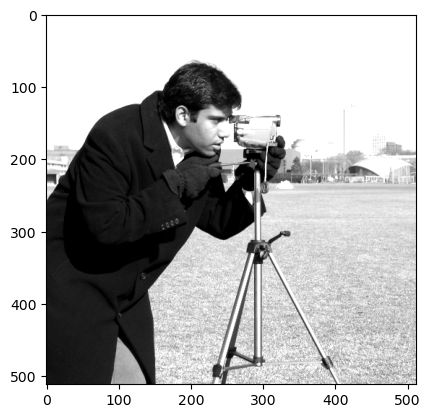

In [38]:
# Histograms and contrast adjustments
camera_high_contrast = exposure.rescale_intensity(camera, in_range=(10, 180))
plt.imshow(camera_high_contrast, cmap='gray')
plt.show()

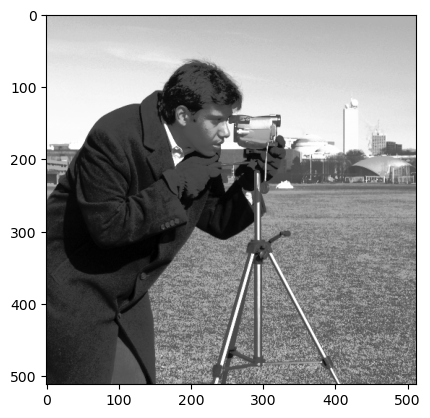

In [39]:
# Equalization
equalized_camera = exposure.equalize_hist(camera)
plt.imshow(equalized_camera, cmap='gray')
plt.show()